In [5]:
!pip install scikit-learn joblib matplotlib pandas

In [6]:
# ==========================================================
# Cell 1 : Import Libraries
# ==========================================================

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

os.makedirs("../images", exist_ok=True)
os.makedirs("../models", exist_ok=True)

cust = pd.read_csv("../data/processed/customer_features.csv")

print("Dataset Shape:", cust.shape)

display(cust.head())

Dataset Shape: (1499, 6)


,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Total_Profit
0,CUST00001,33,13,11840.03,910.771538,4144.01
1,CUST00002,52,6,9185.05,1530.841667,3214.77
2,CUST00003,45,10,10418.25,1041.825000,3646.40
3,CUST00004,167,14,18872.18,1348.012857,6605.26
4,CUST00005,74,10,7634.95,763.495000,2672.22


In [7]:
# ==========================================================
# Cell 2 : Standardize RFM Features
# ==========================================================

features = [
    "Recency",
    "Frequency",
    "Monetary"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cust[features])

print("Scaling Completed!")

Scaling Completed!


C:\Users\Shree\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Shree\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Shree\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Shree\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Shree\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

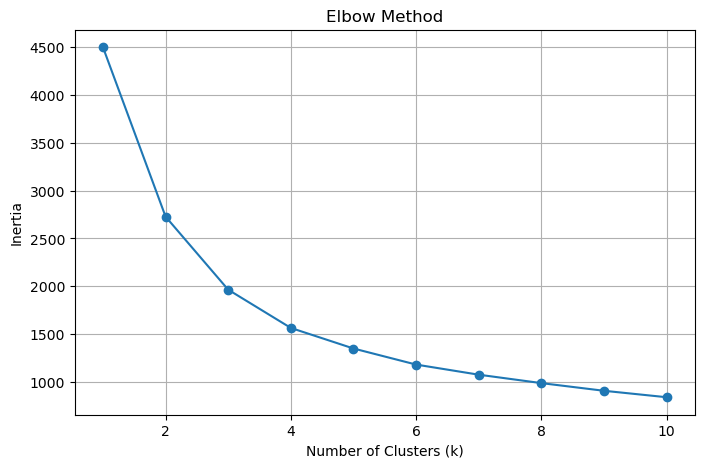

In [8]:
# ==========================================================
# Cell 3 : Elbow Method
# ==========================================================

inertia = []

for k in range(1, 11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.savefig(
    "../images/elbow_method.png",
    dpi=300
)

plt.show()

In [9]:
# ==========================================================
# Cell 4 : Train KMeans
# ==========================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cust["Segment"] = kmeans.fit_predict(X_scaled)

print("Customer Segmentation Completed!")

Customer Segmentation Completed!


C:\Users\Shree\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [10]:
# ==========================================================
# Cell 5 : Segment Summary
# ==========================================================

segment_summary = (
    cust.groupby("Segment")[features]
        .mean()
        .round(2)
)

display(segment_summary)

,Recency,Frequency,Monetary
Segment,,,
0,50.97,14.25,15342.96
1,67.49,10.22,10008.29
2,50.69,18.64,21965.33
3,243.45,10.92,11793.08


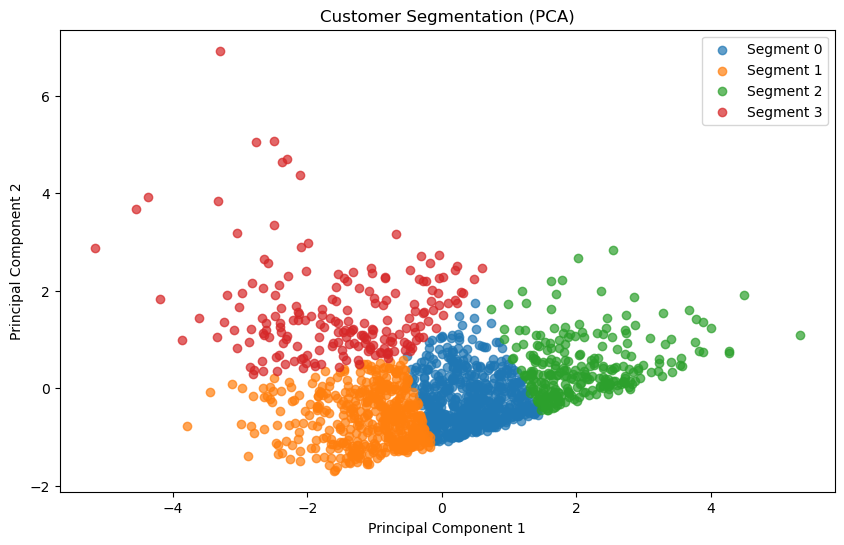

In [11]:
# ==========================================================
# Cell 6 : PCA Visualization
# ==========================================================

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

cust["PCA1"] = pca_result[:,0]
cust["PCA2"] = pca_result[:,1]

plt.figure(figsize=(10,6))

for seg in sorted(cust["Segment"].unique()):

    subset = cust[cust["Segment"] == seg]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        alpha=0.7,
        label=f"Segment {seg}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation (PCA)")
plt.legend()

plt.savefig(
    "../images/customer_segments.png",
    dpi=300
)

plt.show()

In [12]:
# ==========================================================
# Cell 7 : Save Results
# ==========================================================

cust.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

joblib.dump(
    kmeans,
    "../models/kmeans_segmentation.pkl"
)

print("Customer Segments Saved Successfully!")

Customer Segments Saved Successfully!


In [13]:
# ==========================================================
# Cell 8 : Final Dataset
# ==========================================================

print("="*60)
print("CUSTOMER SEGMENTATION COMPLETED")
print("="*60)

print("Dataset Shape :", cust.shape)

display(cust.head())

CUSTOMER SEGMENTATION COMPLETED
Dataset Shape : (1499, 9)


,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Total_Profit,Segment,PCA1,PCA2
0,CUST00001,33,13,11840.03,910.771538,4144.01,0,-0.170404,-0.730566
1,CUST00002,52,6,9185.05,1530.841667,3214.77,1,-1.872046,-1.067691
2,CUST00003,45,10,10418.25,1041.825000,3646.40,1,-0.953676,-0.849039
3,CUST00004,167,14,18872.18,1348.012857,6605.26,0,0.303856,1.299811
4,CUST00005,74,10,7634.95,763.495000,2672.22,1,-1.442876,-0.694626
